# PHASE 3 — ANALYSIS 3.2: Actor Role Analysis

**Menjawab RQ2:** How do grassroots accounts act as 'diffusion drivers' in driving diffusion depth, compared to mega/institutional accounts that only act as 'attention sinks'?

**Tiga Komponen:**
1. Attention Sink vs Diffusion Driver Classification (structural behavior)
2. Depth Contribution per Account Type (hop-level dominance)
3. @barengwarga Case Study (elite attention sink vs grassroot diffusion)

**Input files:**
- `Data_with_community2.csv`
- `Data_diffusion_analysis2.csv`
- `network_nodes_with_community2.csv`
- `network_edges.csv`
- `penetration_by_narrative.csv`

## Cell 1: Import & Load

In [1]:
!pip install networkx -q

import pandas as pd
import numpy as np
import networkx as nx
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('Data_with_community2.csv')
df['date'] = pd.to_datetime(df['date'])
df_diff = pd.read_csv('Data_diffusion_analysis2.csv')
nodes = pd.read_csv('network_nodes_with_community2.csv')
edges_raw = pd.read_csv('network_edges.csv')

# Merge diffusion score
df = df.merge(df_diff[['tweet_url', 'diffusion_score']], on='tweet_url', how='left')

engagement_cols = ['retweet_count', 'reply_count', 'quote_count', 'favorite_count', 'view_count']
for col in engagement_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
df['total_engagement'] = df[engagement_cols].sum(axis=1)

# Community lookup
community_lookup = dict(zip(nodes['username'], nodes['community']))
account_type_lookup = dict(zip(nodes['username'], nodes['account_type']))

print(f"Tweets: {len(df)}")
print(f"Nodes: {len(nodes)}")
print(f"\nNode account_type distribution:")
print(nodes['account_type'].value_counts())
print(f"\nNode degree stats:")
print(nodes[['in_degree', 'out_degree']].describe().round(2))

Tweets: 14248
Nodes: 11426

Node account_type distribution:
account_type
grassroot          11189
media/news           119
elite/political      118
Name: count, dtype: int64

Node degree stats:
       in_degree  out_degree
count   11426.00    11426.00
mean        1.22        1.22
std         9.96        2.87
min         0.00        0.00
25%         0.00        0.00
50%         0.00        1.00
75%         1.00        1.00
max       621.00       84.00


---
# KOMPONEN 1: ATTENTION SINK vs DIFFUSION DRIVER CLASSIFICATION

Klasifikasi setiap node berdasarkan perilaku struktural:
- **Attention Sink**: in-degree tinggi, out-degree rendah (menarik perhatian, tidak menyebarkan)
- **Diffusion Driver**: out-degree tinggi, aktif lintas komunitas (menyebarkan narasi)
- **Bridge**: aktif di kedua arah
- **Peripheral**: low activity di kedua arah

## Cell 2: Build Cross-Community Activity per Node

In [2]:
# Rekonstruksi edges dengan community info
edge_records = []

for _, row in df.iterrows():
    source = str(row.get('username_clean', row['username'])).lower().strip().replace('@', '')
    account_type = row['account_type']

    targets = []
    if pd.notna(row.get('in_reply_to_screen_name')):
        targets.append(str(row['in_reply_to_screen_name']).lower().strip().replace('@', ''))
    if pd.notna(row.get('quoted_username')):
        targets.append(str(row['quoted_username']).lower().strip().replace('@', ''))
    if pd.notna(row.get('mentions')):
        for m in str(row['mentions']).replace('@', '').split():
            if m.strip():
                targets.append(m.lower().strip())

    for target in targets:
        if source != target:
            s_comm = community_lookup.get(source)
            t_comm = community_lookup.get(target)
            is_cross = (s_comm is not None and t_comm is not None and s_comm != t_comm)
            edge_records.append({
                'source': source, 'target': target,
                'source_account_type': account_type,
                'source_community': s_comm,
                'target_community': t_comm,
                'is_cross_community': is_cross
            })

df_edges = pd.DataFrame(edge_records)

# Per-node cross-community outgoing activity
cross_out = df_edges[df_edges['is_cross_community']].groupby('source').size().reset_index(name='cross_comm_out')
total_out = df_edges.groupby('source').size().reset_index(name='total_out')

# Per-node incoming activity
cross_in = df_edges[df_edges['is_cross_community']].groupby('target').size().reset_index(name='cross_comm_in')
total_in = df_edges.groupby('target').size().reset_index(name='total_in')

# Unique communities reached (outgoing)
comms_reached = df_edges[df_edges['is_cross_community']].groupby('source')['target_community'].nunique().reset_index(name='communities_reached_out')

# Merge all into nodes
node_roles = nodes[['username', 'community', 'account_type', 'in_degree', 'out_degree']].copy()
node_roles = node_roles.merge(cross_out, left_on='username', right_on='source', how='left').drop(columns='source', errors='ignore')
node_roles = node_roles.merge(total_out, left_on='username', right_on='source', how='left').drop(columns='source', errors='ignore')
node_roles = node_roles.merge(cross_in, left_on='username', right_on='target', how='left').drop(columns='target', errors='ignore')
node_roles = node_roles.merge(total_in, left_on='username', right_on='target', how='left').drop(columns='target', errors='ignore')
node_roles = node_roles.merge(comms_reached, left_on='username', right_on='source', how='left').drop(columns='source', errors='ignore')

node_roles = node_roles.fillna(0)
for col in ['cross_comm_out', 'total_out', 'cross_comm_in', 'total_in', 'communities_reached_out']:
    node_roles[col] = node_roles[col].astype(int)

# Cross-community ratio (outgoing)
node_roles['cross_ratio_out'] = np.where(
    node_roles['total_out'] > 0,
    node_roles['cross_comm_out'] / node_roles['total_out'],
    0
)

print(f"Node roles table: {len(node_roles)} nodes")
print(f"\nSample (top 10 by in_degree):")
print(node_roles.nlargest(10, 'in_degree')[['username', 'account_type', 'in_degree', 'out_degree',
    'cross_comm_out', 'cross_comm_in', 'communities_reached_out', 'cross_ratio_out']].to_string(index=False))

Node roles table: 11426 nodes

Sample (top 10 by in_degree):
      username    account_type  in_degree  out_degree  cross_comm_out  cross_comm_in  communities_reached_out  cross_ratio_out
       prabowo elite/political        621           0               0            335                        0         0.000000
        dpr_ri elite/political        483           0               0            208                        0         0.000000
   txtdrimedia      media/news        307           0               0            130                        0         0.000000
   barengwarga elite/political        261           3               2             83                        2         0.666667
    tempodotco      media/news        206           0               0            123                        0         0.000000
     kompascom      media/news        195           0               0            136                        0         0.000000
divhumas_polri elite/political        160         

## Cell 3: Structural Role Classification

In [3]:
# Thresholds based on percentiles
# Use nodes with at least some activity
active_nodes = node_roles[(node_roles['in_degree'] > 0) | (node_roles['out_degree'] > 0)].copy()

in_median = active_nodes['in_degree'].median()
out_median = active_nodes['out_degree'].median()
in_p75 = active_nodes['in_degree'].quantile(0.75)
out_p75 = active_nodes['out_degree'].quantile(0.75)

print(f"Active nodes: {len(active_nodes)}")
print(f"In-degree: median={in_median}, P75={in_p75}")
print(f"Out-degree: median={out_median}, P75={out_p75}")

# Classification
def classify_role(row):
    high_in = row['in_degree'] >= in_p75
    high_out = row['out_degree'] >= out_p75
    has_cross = row['cross_comm_out'] > 0

    if high_in and not high_out:
        return 'Attention Sink'
    elif high_out and has_cross:
        return 'Diffusion Driver'
    elif high_out and not has_cross:
        return 'Local Amplifier'
    elif high_in and high_out:
        return 'Bridge'
    else:
        return 'Peripheral'

active_nodes['structural_role'] = active_nodes.apply(classify_role, axis=1)

print(f"\n{'=' * 70}")
print("STRUCTURAL ROLE DISTRIBUTION")
print("=" * 70)
print(active_nodes['structural_role'].value_counts())

# Cross-tab: structural role x account type
print(f"\n{'=' * 70}")
print("STRUCTURAL ROLE x ACCOUNT TYPE (counts)")
print("=" * 70)
ct = pd.crosstab(active_nodes['structural_role'], active_nodes['account_type'])
print(ct)

print(f"\n{'=' * 70}")
print("STRUCTURAL ROLE x ACCOUNT TYPE (row %)")
print("=" * 70)
ct_pct = pd.crosstab(active_nodes['structural_role'], active_nodes['account_type'], normalize='index') * 100
print(ct_pct.round(1))

print(f"\n{'=' * 70}")
print("ACCOUNT TYPE x STRUCTURAL ROLE (column % — what role does each type play?)")
print("=" * 70)
ct_col = pd.crosstab(active_nodes['structural_role'], active_nodes['account_type'], normalize='columns') * 100
print(ct_col.round(1))

Active nodes: 11426
In-degree: median=0.0, P75=1.0
Out-degree: median=1.0, P75=1.0

STRUCTURAL ROLE DISTRIBUTION
structural_role
Local Amplifier     6163
Attention Sink      4253
Diffusion Driver    1010
Name: count, dtype: int64

STRUCTURAL ROLE x ACCOUNT TYPE (counts)
account_type      elite/political  grassroot  media/news
structural_role                                         
Attention Sink                102       4043         108
Diffusion Driver                7       1002           1
Local Amplifier                 9       6144          10

STRUCTURAL ROLE x ACCOUNT TYPE (row %)
account_type      elite/political  grassroot  media/news
structural_role                                         
Attention Sink                2.4       95.1         2.5
Diffusion Driver              0.7       99.2         0.1
Local Amplifier               0.1       99.7         0.2

ACCOUNT TYPE x STRUCTURAL ROLE (column % — what role does each type play?)
account_type      elite/political  grassroo

## Cell 4: Statistical Test — Role Distribution by Account Type

In [4]:
# Chi-squared: is structural role distribution independent of account type?
ct_test = pd.crosstab(active_nodes['structural_role'], active_nodes['account_type'])
chi2, p, dof, expected = stats.chi2_contingency(ct_test)

print("=" * 70)
print("CHI-SQUARED: STRUCTURAL ROLE vs ACCOUNT TYPE")
print("=" * 70)
print(f"Chi2 = {chi2:.4f}, p = {p:.6f}, dof = {dof}")
print(f"{'Significant' if p < 0.05 else 'Not significant'} at alpha=0.05")

# Mann-Whitney: Do grassroot nodes have higher cross-community out-degree than elite?
print(f"\n{'=' * 70}")
print("MANN-WHITNEY: CROSS-COMMUNITY OUT-DEGREE BY ACCOUNT TYPE")
print("=" * 70)

for at1, at2 in [('grassroot', 'elite/political'), ('grassroot', 'media/news'), ('elite/political', 'media/news')]:
    g1 = active_nodes[active_nodes['account_type'] == at1]['cross_comm_out']
    g2 = active_nodes[active_nodes['account_type'] == at2]['cross_comm_out']

    if len(g1) >= 5 and len(g2) >= 5:
        u, p_mw = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        r = 1 - (2 * u) / (len(g1) * len(g2))
        sig = '***' if p_mw < 0.001 else '**' if p_mw < 0.01 else '*' if p_mw < 0.05 else 'ns'

        print(f"\n{at1} vs {at2}:")
        print(f"  {at1}: n={len(g1)}, mean={g1.mean():.3f}, median={g1.median():.1f}")
        print(f"  {at2}: n={len(g2)}, mean={g2.mean():.3f}, median={g2.median():.1f}")
        print(f"  U={u:.0f}, p={p_mw:.6f}, r={r:.3f} {sig}")

CHI-SQUARED: STRUCTURAL ROLE vs ACCOUNT TYPE
Chi2 = 276.5200, p = 0.000000, dof = 4
Significant at alpha=0.05

MANN-WHITNEY: CROSS-COMMUNITY OUT-DEGREE BY ACCOUNT TYPE

grassroot vs elite/political:
  grassroot: n=11189, mean=0.290, median=0.0
  elite/political: n=118, mean=0.110, median=0.0
  U=680389, p=0.245853, r=-0.031 ns

grassroot vs media/news:
  grassroot: n=11189, mean=0.290, median=0.0
  media/news: n=119, mean=0.008, median=0.0
  U=720020, p=0.001886, r=-0.082 **

elite/political vs media/news:
  elite/political: n=118, mean=0.110, median=0.0
  media/news: n=119, mean=0.008, median=0.0
  U=7380, p=0.029903, r=-0.051 *


## Cell 5: Top Actors per Role

In [5]:
print("=" * 80)
print("TOP 10 ATTENTION SINKS (highest in-degree, low out-degree)")
print("=" * 80)

sinks = active_nodes[active_nodes['structural_role'] == 'Attention Sink'].nlargest(10, 'in_degree')
print(sinks[['username', 'account_type', 'in_degree', 'out_degree',
             'cross_comm_out', 'cross_comm_in', 'communities_reached_out']].to_string(index=False))

print(f"\n{'=' * 80}")
print("TOP 10 DIFFUSION DRIVERS (highest cross-community out-degree)")
print("=" * 80)

drivers = active_nodes[active_nodes['structural_role'] == 'Diffusion Driver'].nlargest(10, 'cross_comm_out')
print(drivers[['username', 'account_type', 'in_degree', 'out_degree',
              'cross_comm_out', 'cross_comm_in', 'communities_reached_out']].to_string(index=False))

print(f"\n{'=' * 80}")
print("TOP 10 BRIDGES (high in AND out, with cross-community activity)")
print("=" * 80)

bridges = active_nodes[active_nodes['structural_role'] == 'Bridge']
if len(bridges) > 0:
    bridges_top = bridges.nlargest(10, 'cross_comm_out')
    print(bridges_top[['username', 'account_type', 'in_degree', 'out_degree',
                       'cross_comm_out', 'cross_comm_in', 'communities_reached_out']].to_string(index=False))
else:
    print("No bridges found.")

TOP 10 ATTENTION SINKS (highest in-degree, low out-degree)
       username    account_type  in_degree  out_degree  cross_comm_out  cross_comm_in  communities_reached_out
        prabowo elite/political        621           0               0            335                        0
         dpr_ri elite/political        483           0               0            208                        0
    txtdrimedia      media/news        307           0               0            130                        0
     tempodotco      media/news        206           0               0            123                        0
      kompascom      media/news        195           0               0            136                        0
 divhumas_polri elite/political        160           0               0             82                        0
       arsipaja      media/news        153           0               0             86                        0
       ipopbase      media/news        140           

## Cell 6: Visualisasi — Structural Role by Account Type

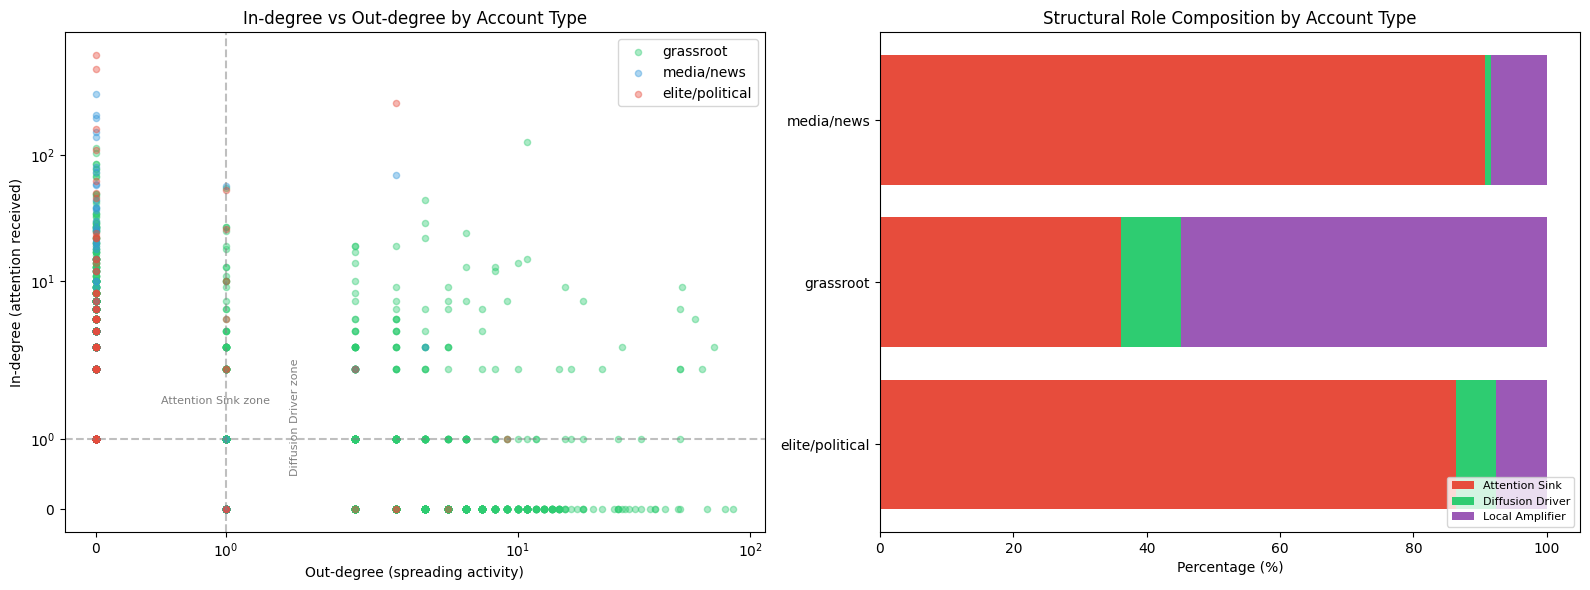

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Scatter — in-degree vs out-degree, colored by account type
color_map = {'grassroot': '#2ecc71', 'media/news': '#3498db', 'elite/political': '#e74c3c'}

for atype in ['grassroot', 'media/news', 'elite/political']:
    subset = active_nodes[active_nodes['account_type'] == atype]
    axes[0].scatter(subset['out_degree'], subset['in_degree'],
                   c=color_map[atype], label=atype, alpha=0.4, s=20)

axes[0].set_xlabel('Out-degree (spreading activity)')
axes[0].set_ylabel('In-degree (attention received)')
axes[0].set_title('In-degree vs Out-degree by Account Type')
axes[0].legend()
axes[0].set_xscale('symlog')
axes[0].set_yscale('symlog')

# Add quadrant lines
axes[0].axhline(y=in_p75, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=out_p75, color='gray', linestyle='--', alpha=0.5)
axes[0].text(0.5, in_p75*1.5, 'Attention Sink zone', fontsize=8, color='gray')
axes[0].text(out_p75*1.5, 0.5, 'Diffusion Driver zone', fontsize=8, color='gray', rotation=90)

# Plot 2: Stacked bar — role composition per account type
role_order = ['Attention Sink', 'Bridge', 'Diffusion Driver', 'Local Amplifier', 'Peripheral']
role_colors = {'Attention Sink': '#e74c3c', 'Bridge': '#f39c12',
               'Diffusion Driver': '#2ecc71', 'Local Amplifier': '#9b59b6', 'Peripheral': '#bdc3c7'}

ct_plot = pd.crosstab(active_nodes['account_type'], active_nodes['structural_role'], normalize='index') * 100

bottom = np.zeros(len(ct_plot))
for role in role_order:
    if role in ct_plot.columns:
        axes[1].barh(ct_plot.index, ct_plot[role], left=bottom,
                    label=role, color=role_colors.get(role, 'gray'))
        bottom += ct_plot[role].values

axes[1].set_xlabel('Percentage (%)')
axes[1].set_title('Structural Role Composition by Account Type')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

---
# KOMPONEN 2: DEPTH CONTRIBUTION PER ACCOUNT TYPE

Di setiap hop level dalam cascade, account type apa yang dominan?
Apakah grassroot mendominasi di hop akhir (deep cascade)?

## Cell 7: Build Cascade with Hop Levels

In [7]:
# Build directed graph from edges
G = nx.DiGraph()
for _, row in df_edges.iterrows():
    if G.has_edge(row['source'], row['target']):
        G[row['source']][row['target']]['weight'] += 1
    else:
        G.add_edge(row['source'], row['target'], weight=1)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Find top attention sinks (highest in-degree) as cascade roots
in_degrees = dict(G.in_degree())
top_sinks = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:20]

print(f"\nTop 10 in-degree nodes (potential cascade roots):")
for username, deg in top_sinks[:10]:
    atype = account_type_lookup.get(username, 'unknown')
    print(f"  @{username} ({atype}): in-degree={deg}")

Graph: 11426 nodes, 13994 edges

Top 10 in-degree nodes (potential cascade roots):
  @prabowo (elite/political): in-degree=621
  @dpr_ri (elite/political): in-degree=483
  @txtdrimedia (media/news): in-degree=307
  @barengwarga (elite/political): in-degree=261
  @tempodotco (media/news): in-degree=206
  @kompascom (media/news): in-degree=195
  @divhumas_polri (elite/political): in-degree=160
  @arsipaja (media/news): in-degree=153
  @ipopbase (media/news): in-degree=140
  @budibukanintel (grassroot): in-degree=127


## Cell 8: BFS Hop Level Analysis

Untuk setiap cascade root (attention sink), trace BFS outward.
Di setiap hop level, hitung berapa nodes dari setiap account type.

In [8]:
# Reverse graph: edges point from target to source
# (karena di social media, reply/quote/mention = info flows TO the target)
# Untuk BFS cascade: kita mau trace siapa yang me-reply/quote/mention sink,
# lalu siapa yang me-reply/quote/mention mereka, dst.
# Jadi kita perlu reverse: edge dari target ke source (info propagation direction)
G_rev = G.reverse()

# BFS from top sinks
def bfs_hop_analysis(graph, root, max_depth=10):
    """BFS from root, return nodes at each hop level with account type."""
    visited = {root}
    current_level = {root}
    hop_data = []

    for hop in range(1, max_depth + 1):
        next_level = set()
        for node in current_level:
            for neighbor in graph.neighbors(node):
                if neighbor not in visited:
                    next_level.add(neighbor)
                    visited.add(neighbor)

        if not next_level:
            break

        for node in next_level:
            atype = account_type_lookup.get(node, 'unknown')
            comm = community_lookup.get(node)
            hop_data.append({
                'hop': hop,
                'username': node,
                'account_type': atype,
                'community': comm
            })

        current_level = next_level

    return pd.DataFrame(hop_data)

# Analyze top 5 sinks
print("=" * 80)
print("BFS HOP LEVEL ANALYSIS — FROM TOP ATTENTION SINKS")
print("=" * 80)

all_hop_data = []

for username, deg in top_sinks[:10]:
    if username not in G_rev:
        continue

    hop_df = bfs_hop_analysis(G_rev, username)
    if len(hop_df) == 0:
        continue

    hop_df['root'] = username
    all_hop_data.append(hop_df)

    atype = account_type_lookup.get(username, 'unknown')
    max_hop = hop_df['hop'].max()
    total_reached = len(hop_df)

    print(f"\n--- @{username} ({atype}, in-degree={deg}) ---")
    print(f"Max hop: {max_hop}, Total nodes reached: {total_reached}")

    hop_summary = hop_df.groupby(['hop', 'account_type']).size().unstack(fill_value=0)
    print(hop_summary)

# Combine all
if all_hop_data:
    df_hops = pd.concat(all_hop_data, ignore_index=True)
    print(f"\nTotal hop records: {len(df_hops)}")

BFS HOP LEVEL ANALYSIS — FROM TOP ATTENTION SINKS

--- @prabowo (elite/political, in-degree=621) ---
Max hop: 5, Total nodes reached: 1257
account_type  elite/political  grassroot  unknown
hop                                              
1                           7        613        1
2                           0        469        0
3                           1        143        0
4                           0         20        0
5                           0          3        0

--- @dpr_ri (elite/political, in-degree=483) ---
Max hop: 5, Total nodes reached: 643
account_type  elite/political  grassroot  unknown
hop                                              
1                           1        481        1
2                           0        123        0
3                           0         29        0
4                           0          7        0
5                           0          1        0

--- @txtdrimedia (media/news, in-degree=307) ---
Max hop: 2, Total nodes 

## Cell 9: Aggregate Hop Level — Account Type Distribution at Each Depth

AGGREGATE: ACCOUNT TYPE AT EACH HOP LEVEL (all cascades combined)

Counts:
account_type  elite/political  grassroot  media/news  unknown
hop                                                          
1                           9       2640           1        3
2                           2        997           0        0
3                           1        241           0        0
4                           0         55           0        0
5                           0         14           0        0
6                           0          3           0        0

Percentages:
account_type  elite/political  grassroot  media/news  unknown
hop                                                          
1                         0.3       99.5         0.0      0.1
2                         0.2       99.8         0.0      0.0
3                         0.4       99.6         0.0      0.0
4                         0.0      100.0         0.0      0.0
5                         0.0      100.0   

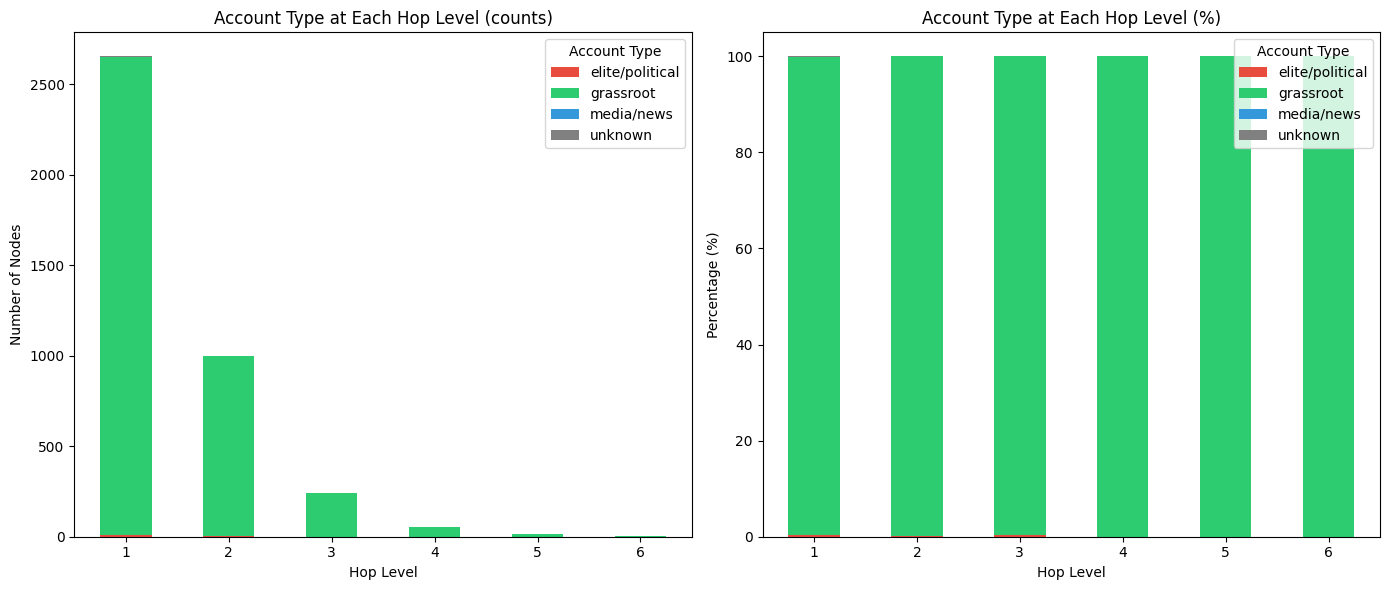


Grassroot % at hop 1: 99.5%
Grassroot % at hop 6: 100.0%


In [9]:
if len(df_hops) > 0:
    print("=" * 70)
    print("AGGREGATE: ACCOUNT TYPE AT EACH HOP LEVEL (all cascades combined)")
    print("=" * 70)

    # Count per hop per account type
    hop_agg = df_hops.groupby(['hop', 'account_type']).size().unstack(fill_value=0)
    hop_agg_pct = hop_agg.div(hop_agg.sum(axis=1), axis=0) * 100

    print("\nCounts:")
    print(hop_agg)
    print("\nPercentages:")
    print(hop_agg_pct.round(1))

    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Stacked bar counts
    hop_agg.plot(kind='bar', stacked=True, ax=axes[0],
                color=[color_map.get(c, 'gray') for c in hop_agg.columns])
    axes[0].set_xlabel('Hop Level')
    axes[0].set_ylabel('Number of Nodes')
    axes[0].set_title('Account Type at Each Hop Level (counts)')
    axes[0].legend(title='Account Type')
    axes[0].tick_params(axis='x', rotation=0)

    # Plot 2: Stacked bar percentages
    hop_agg_pct.plot(kind='bar', stacked=True, ax=axes[1],
                    color=[color_map.get(c, 'gray') for c in hop_agg_pct.columns])
    axes[1].set_xlabel('Hop Level')
    axes[1].set_ylabel('Percentage (%)')
    axes[1].set_title('Account Type at Each Hop Level (%)')
    axes[1].legend(title='Account Type')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

    # Key finding: grassroot % at deepest hops
    if 'grassroot' in hop_agg_pct.columns:
        print(f"\nGrassroot % at hop 1: {hop_agg_pct.loc[1, 'grassroot']:.1f}%")
        max_hop = hop_agg_pct.index.max()
        print(f"Grassroot % at hop {max_hop}: {hop_agg_pct.loc[max_hop, 'grassroot']:.1f}%")

---
# KOMPONEN 3: @barengwarga CASE STUDY

Kontras antara attention sink (@barengwarga) vs grassroot diffusion drivers.

## Cell 10: @barengwarga Profile — Attention Sink Evidence

In [10]:
bw_username = 'barengwarga'

# Tweet-level stats
bw_tweets = df[df['username'].str.lower().str.strip().str.replace('@', '') == bw_username]

# Network-level stats
bw_node = node_roles[node_roles['username'].str.lower() == bw_username]

# Edges involving @barengwarga
bw_edges_out = df_edges[df_edges['source'] == bw_username]
bw_edges_in = df_edges[df_edges['target'] == bw_username]

print("=" * 70)
print("@barengwarga — ATTENTION SINK PROFILE")
print("=" * 70)

print(f"\n--- Tweet Activity ---")
print(f"Total tweets: {len(bw_tweets)}")
print(f"Total engagement: {bw_tweets['total_engagement'].sum():,.0f}")
print(f"Mean engagement per tweet: {bw_tweets['total_engagement'].mean():,.0f}")
print(f"% of dataset engagement: {bw_tweets['total_engagement'].sum() / df['total_engagement'].sum() * 100:.1f}%")

print(f"\n--- Network Position ---")
if len(bw_node) > 0:
    row = bw_node.iloc[0]
    print(f"In-degree: {int(row['in_degree'])}")
    print(f"Out-degree: {int(row['out_degree'])}")
    print(f"In/Out ratio: {row['in_degree']/max(row['out_degree'],1):.1f}")
    print(f"Community: {int(row['community'])}")
    print(f"Cross-community out: {int(row['cross_comm_out'])}")
    print(f"Cross-community in: {int(row['cross_comm_in'])}")
    print(f"Communities reached (out): {int(row['communities_reached_out'])}")

print(f"\n--- Edge Analysis ---")
print(f"Outgoing edges: {len(bw_edges_out)}")
print(f"Incoming edges: {len(bw_edges_in)}")
if len(bw_edges_out) > 0:
    bw_cross_out = bw_edges_out['is_cross_community'].sum()
    print(f"Outgoing cross-community: {bw_cross_out} ({bw_cross_out/len(bw_edges_out)*100:.1f}%)")
if len(bw_edges_in) > 0:
    bw_cross_in = bw_edges_in['is_cross_community'].sum()
    print(f"Incoming cross-community: {bw_cross_in} ({bw_cross_in/len(bw_edges_in)*100:.1f}%)")
    # How many communities send edges TO @barengwarga?
    comms_in = bw_edges_in['source_community'].dropna().nunique()
    print(f"Communities sending edges to @barengwarga: {comms_in}")

@barengwarga — ATTENTION SINK PROFILE

--- Tweet Activity ---
Total tweets: 11
Total engagement: 7,006,498
Mean engagement per tweet: 636,954
% of dataset engagement: 22.0%

--- Network Position ---
In-degree: 261
Out-degree: 3
In/Out ratio: 87.0
Community: 7
Cross-community out: 2
Cross-community in: 83
Communities reached (out): 2

--- Edge Analysis ---
Outgoing edges: 3
Incoming edges: 366
Outgoing cross-community: 2 (66.7%)
Incoming cross-community: 83 (22.7%)
Communities sending edges to @barengwarga: 24


## Cell 11: Contrast — Top Grassroot Diffusion Drivers vs @barengwarga

In [17]:
# Top 5 grassroot diffusion drivers
top_grassroot_drivers = active_nodes[
    (active_nodes['account_type'] == 'grassroot') &
    (active_nodes['structural_role'] == 'Diffusion Driver')
].nlargest(5, 'cross_comm_out')

print("=" * 80)
print("CONTRAST: @barengwarga (Attention Sink) vs TOP 5 GRASSROOT DIFFUSION DRIVERS")
print("=" * 80)

# Build comparison table
comparison = []

# barengwarga
if len(bw_node) > 0:
    bw = bw_node.iloc[0]
    bw_tweet_data = bw_tweets
    comparison.append({
        'username': '@barengwarga',
        'account_type': 'elite/political',
        'structural_role': 'Attention Sink',
        'tweets': len(bw_tweet_data),
        'total_engagement': int(bw_tweet_data['total_engagement'].sum()),
        'in_degree': int(bw['in_degree']),
        'out_degree': int(bw['out_degree']),
        'cross_comm_out': int(bw['cross_comm_out']),
        'communities_reached': int(bw['communities_reached_out']),
        'cross_ratio_out': round(bw['cross_ratio_out'], 3)
    })

# Top grassroot drivers
for _, driver in top_grassroot_drivers.iterrows():
    driver_tweets = df[df['username'].str.lower().str.strip().str.replace('@', '') == driver['username'].lower()]
    comparison.append({
        'username': f"@{driver['username']}",
        'account_type': 'grassroot',
        'structural_role': 'Diffusion Driver',
        'tweets': len(driver_tweets),
        'total_engagement': int(driver_tweets['total_engagement'].sum()),
        'in_degree': int(driver['in_degree']),
        'out_degree': int(driver['out_degree']),
        'cross_comm_out': int(driver['cross_comm_out']),
        'communities_reached': int(driver['communities_reached_out']),
        'cross_ratio_out': round(driver['cross_ratio_out'], 3)
    })

df_compare = pd.DataFrame(comparison)
print(df_compare.to_string(index=False))

# Key insight
if len(comparison) > 1:
    bw_eng = comparison[0]['total_engagement']
    bw_cross = comparison[0]['cross_comm_out']
    bw_comms = comparison[0]['communities_reached']

    avg_driver_eng = np.mean([c['total_engagement'] for c in comparison[1:]])
    avg_driver_cross = np.mean([c['cross_comm_out'] for c in comparison[1:]])
    avg_driver_comms = np.mean([c['communities_reached'] for c in comparison[1:]])

    print(f"\n--- KEY CONTRAST ---")
    print(f"@barengwarga: {bw_eng:,} engagement, {bw_cross} cross-community edges, {bw_comms} communities")
    print(f"Avg top grassroot driver: {avg_driver_eng:,.0f} engagement, {avg_driver_cross:.0f} cross-community edges, {avg_driver_comms:.0f} communities")
    print(f"\nEngagement ratio (barengwarga/avg driver): {bw_eng/max(avg_driver_eng,1):.1f}x")
    print(f"Cross-comm ratio (avg driver/barengwarga): {avg_driver_cross/max(bw_cross,1):.1f}x")

CONTRAST: @barengwarga (Attention Sink) vs TOP 5 GRASSROOT DIFFUSION DRIVERS
       username    account_type  structural_role  tweets  total_engagement  in_degree  out_degree  cross_comm_out  communities_reached  cross_ratio_out
   @barengwarga elite/political   Attention Sink      11           7006498        261           3               2                    2            0.667
       @bincjun       grassroot Diffusion Driver      93             50365          0          78             105                   17            0.550
      @flinus23       grassroot Diffusion Driver      96             16378          0          49              99                   10            0.414
         @g0rip       grassroot Diffusion Driver     102             13792          0          39              95                   20            0.432
@jannahseeker99       grassroot Diffusion Driver     113             32733          3          70              94                   20            0.522
   @suharto

## Cell 12: Engagement vs Structural Impact — All Account Types

CORRELATION: ENGAGEMENT vs CROSS-COMMUNITY ACTIVITY

All users: Spearman rho=0.189, p=0.000000
grassroot: rho=0.193, p=0.000000 (n=7498)
media/news: rho=0.088, p=0.520875 (n=56)
elite/political: rho=0.054, p=0.769949 (n=32)


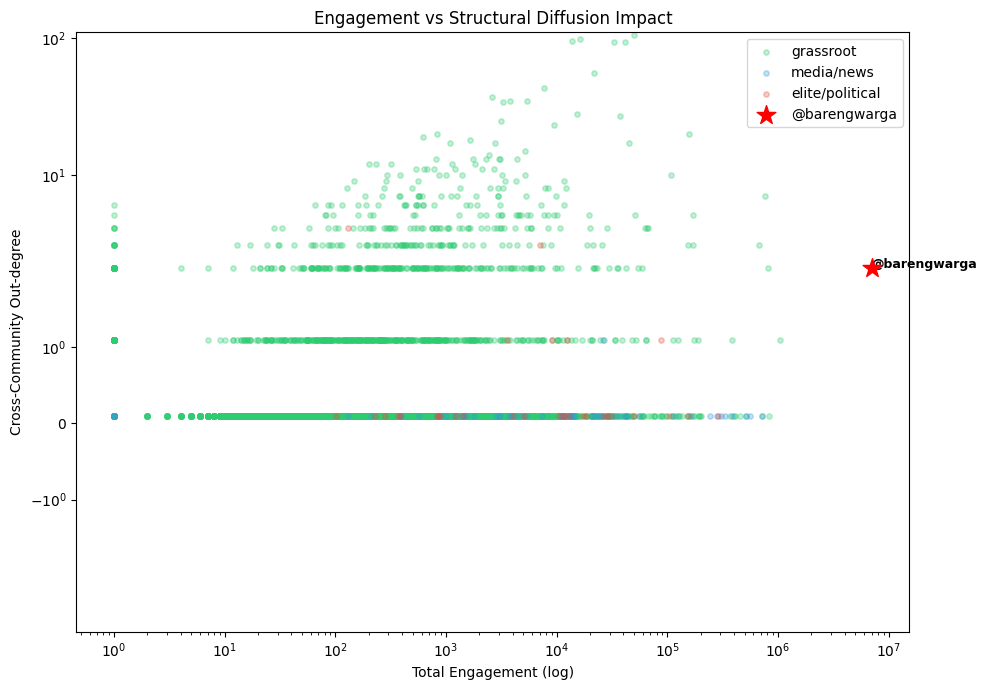


Interpretation: Points in upper-left = high structural impact, low engagement (diffusion drivers)
Points in lower-right = high engagement, low structural impact (attention sinks)


In [12]:
# Per-user: engagement vs cross-community activity
user_eng = df.groupby('username').agg(
    total_engagement=('total_engagement', 'sum'),
    n_tweets=('total_engagement', 'size'),
    account_type=('account_type', 'first')
).reset_index()

user_eng['username_clean'] = user_eng['username'].str.lower().str.strip().str.replace('@', '')

# Merge with node roles
node_roles_clean = node_roles.copy()
node_roles_clean['username_clean'] = node_roles_clean['username'].str.lower().str.strip()

user_full = user_eng.merge(node_roles_clean[['username_clean', 'cross_comm_out', 'communities_reached_out']],
                           on='username_clean', how='left').fillna(0)

# Correlation: engagement vs cross-community activity
print("=" * 70)
print("CORRELATION: ENGAGEMENT vs CROSS-COMMUNITY ACTIVITY")
print("=" * 70)

rho, p = stats.spearmanr(user_full['total_engagement'], user_full['cross_comm_out'])
print(f"\nAll users: Spearman rho={rho:.3f}, p={p:.6f}")

for atype in ['grassroot', 'media/news', 'elite/political']:
    subset = user_full[user_full['account_type'] == atype]
    if len(subset) >= 5:
        rho_a, p_a = stats.spearmanr(subset['total_engagement'], subset['cross_comm_out'])
        print(f"{atype}: rho={rho_a:.3f}, p={p_a:.6f} (n={len(subset)})")

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 7))

for atype in ['grassroot', 'media/news', 'elite/political']:
    subset = user_full[user_full['account_type'] == atype]
    ax.scatter(subset['total_engagement'] + 1, subset['cross_comm_out'] + 0.1,
              c=color_map[atype], label=atype, alpha=0.3, s=15)

# Highlight @barengwarga
bw_row = user_full[user_full['username_clean'] == 'barengwarga']
if len(bw_row) > 0:
    ax.scatter(bw_row['total_engagement'] + 1, bw_row['cross_comm_out'] + 0.1,
              c='red', s=200, marker='*', zorder=5, label='@barengwarga')
    ax.annotate('@barengwarga',
               (bw_row['total_engagement'].values[0] + 1, bw_row['cross_comm_out'].values[0] + 0.1),
               fontsize=9, fontweight='bold')

ax.set_xscale('log')
ax.set_yscale('symlog')
ax.set_xlabel('Total Engagement (log)')
ax.set_ylabel('Cross-Community Out-degree')
ax.set_title('Engagement vs Structural Diffusion Impact')
ax.legend()
plt.tight_layout()
plt.show()

print("\nInterpretation: Points in upper-left = high structural impact, low engagement (diffusion drivers)")
print("Points in lower-right = high engagement, low structural impact (attention sinks)")

## Cell 13: Summary Statistics for Paper

In [13]:
print("=" * 80)
print("ANALYSIS 3.2 — SUMMARY FOR PAPER")
print("=" * 80)

# 1. Role distribution
print("\n1. STRUCTURAL ROLE DISTRIBUTION")
print(active_nodes['structural_role'].value_counts())

# 2. Grassroot dominance in diffusion
drivers_all = active_nodes[active_nodes['structural_role'] == 'Diffusion Driver']
grassroot_drivers = drivers_all[drivers_all['account_type'] == 'grassroot']
print(f"\n2. GRASSROOT AS DIFFUSION DRIVERS")
print(f"Total diffusion drivers: {len(drivers_all)}")
print(f"Grassroot diffusion drivers: {len(grassroot_drivers)} ({len(grassroot_drivers)/len(drivers_all)*100:.1f}%)")

# 3. Elite as attention sinks
sinks_all = active_nodes[active_nodes['structural_role'] == 'Attention Sink']
elite_sinks = sinks_all[sinks_all['account_type'] == 'elite/political']
print(f"\n3. ELITE AS ATTENTION SINKS")
print(f"Total attention sinks: {len(sinks_all)}")
print(f"Elite attention sinks: {len(elite_sinks)}")
# What % of elite nodes are attention sinks?
elite_total = len(active_nodes[active_nodes['account_type'] == 'elite/political'])
print(f"% of elite nodes that are attention sinks: {len(elite_sinks)/max(elite_total,1)*100:.1f}%")

# 4. Cross-community dominance
print(f"\n4. CROSS-COMMUNITY ACTIVITY")
cross_edges_total = df_edges['is_cross_community'].sum()
cross_by_grassroot = df_edges[(df_edges['is_cross_community']) & (df_edges['source_account_type'] == 'grassroot')].shape[0]
print(f"Total cross-community edges: {cross_edges_total}")
print(f"From grassroot: {cross_by_grassroot} ({cross_by_grassroot/cross_edges_total*100:.1f}%)")

# 5. @barengwarga contrast
print(f"\n5. @barengwarga CASE")
print(f"Tweets: {len(bw_tweets)}, Engagement: {bw_tweets['total_engagement'].sum():,.0f}")
print(f"% of dataset engagement: {bw_tweets['total_engagement'].sum()/df['total_engagement'].sum()*100:.1f}%")
if len(bw_node) > 0:
    print(f"Cross-community out: {int(bw_node.iloc[0]['cross_comm_out'])}")
    print(f"Communities reached: {int(bw_node.iloc[0]['communities_reached_out'])}")

ANALYSIS 3.2 — SUMMARY FOR PAPER

1. STRUCTURAL ROLE DISTRIBUTION
structural_role
Local Amplifier     6163
Attention Sink      4253
Diffusion Driver    1010
Name: count, dtype: int64

2. GRASSROOT AS DIFFUSION DRIVERS
Total diffusion drivers: 1010
Grassroot diffusion drivers: 1002 (99.2%)

3. ELITE AS ATTENTION SINKS
Total attention sinks: 4253
Elite attention sinks: 102
% of elite nodes that are attention sinks: 86.4%

4. CROSS-COMMUNITY ACTIVITY
Total cross-community edges: 3258
From grassroot: 3244 (99.6%)

5. @barengwarga CASE
Tweets: 11, Engagement: 7,006,498
% of dataset engagement: 22.0%
Cross-community out: 2
Communities reached: 2


## Cell 14: Export

In [14]:
# Export node roles
active_nodes.to_csv('actor_roles_classification.csv', index=False)

# Export comparison
df_compare.to_csv('actor_comparison_sink_vs_driver.csv', index=False)

# Export hop data
if len(df_hops) > 0:
    df_hops.to_csv('cascade_hop_levels.csv', index=False)

from google.colab import files
files.download('actor_roles_classification.csv')
files.download('actor_comparison_sink_vs_driver.csv')
if len(df_hops) > 0:
    files.download('cascade_hop_levels.csv')

print("Files exported:")
print("1. actor_roles_classification.csv — all nodes with structural role")
print("2. actor_comparison_sink_vs_driver.csv — @barengwarga vs top drivers")
print("3. cascade_hop_levels.csv — BFS hop level data")
print("\nAnalysis 3.2 (Actor Role Analysis) COMPLETE.")
print("Next: Analysis 3.3 (Cross-Community Penetration & Cognitive Fusion)")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files exported:
1. actor_roles_classification.csv — all nodes with structural role
2. actor_comparison_sink_vs_driver.csv — @barengwarga vs top drivers
3. cascade_hop_levels.csv — BFS hop level data

Analysis 3.2 (Actor Role Analysis) COMPLETE.
Next: Analysis 3.3 (Cross-Community Penetration & Cognitive Fusion)
